# Flooded Area Detection using Morphological Operators

**FURB 2024.2 — Image Processing**  
Author: Leonardo Gian Pottmayer

The goal of this notebook is to identify areas that were flooded by comparing two satellite images of the same region: one captured during the rainy season and one during the dry season. Detection is performed by applying a sequence of morphological and pre-processing operations to both images.

## Imports

In [1]:
from dataclasses import dataclass
import os
import re
import sys

import cv2
import numpy as np
import matplotlib.pyplot as plt

## Configuration

All pipeline parameters are centralized in the `Config` dataclass. This makes tuning straightforward: adjust binarization thresholds, brightness levels, kernel size, or enable the optional cleanup pass — all from one place without touching the processing functions.

In [2]:
@dataclass
class Config:
    # Paths
    rainy_image_path: str = "images/raw/rainy.png"
    dry_image_path: str = "images/raw/dry.png"
    debug_dir: str = "images/debug"

    # Display
    show_images: bool = True

    # Brightness increment after inversion (added to pixel values)
    rainy_brightness: int = 60
    dry_brightness: int = 50

    # Morphology kernel size (height, width)
    kernel_shape: tuple = (1, 1)

    # Morphology iterations
    dilate_iterations: int = 1
    erode_iterations: int = 5

    # Binarization thresholds
    rainy_threshold: int = 205
    dry_threshold: int = 240

    # Overlay color for flooded areas in BGR
    overlay_color: tuple = (255, 120, 40)

    # Optional light morphological cleanup on the final flood mask to reduce noise
    apply_cleanup: bool = False
    cleanup_kernel_shape: tuple = (3, 3)
    cleanup_iterations: int = 1

## Helper Functions

Each pipeline stage is encapsulated in its own function. `save_debug_step` handles both saving the result to disk and displaying it inline in the notebook. The `plt.close(fig)` call is what ensures each image renders immediately in place rather than all accumulating at the end of the cell.

In [3]:
def prepare_debug_dir(config: Config) -> None:
    if not os.path.exists(config.debug_dir):
        os.makedirs(config.debug_dir)
    for f in os.listdir(config.debug_dir):
        os.remove(os.path.join(config.debug_dir, f))


def slugify_step_title(title: str) -> str:
    slug = re.sub(r"[^a-z0-9]+", "-", title.lower()).strip("-")
    return slug


def save_debug_step(config: Config, step: int, title: str, img: np.ndarray) -> None:
    filename = f"{step:02d}-{slugify_step_title(title)}.png"
    path = os.path.join(config.debug_dir, filename)
    cv2.imwrite(path, img)

    if config.show_images:
        fig, ax = plt.subplots()
        if img.ndim == 2:
            ax.imshow(img, cmap="gray")
        else:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(f"{step:02d} - {title}")
        ax.axis("off")
        plt.show()
        plt.close(fig)


def load_grayscale_images(config: Config) -> tuple[np.ndarray, np.ndarray]:
    for path in (config.rainy_image_path, config.dry_image_path):
        if not os.path.exists(path):
            sys.exit(f"Error: file not found: {path}")

    rainy = cv2.imread(config.rainy_image_path, cv2.IMREAD_GRAYSCALE)
    dry = cv2.imread(config.dry_image_path, cv2.IMREAD_GRAYSCALE)

    if rainy is None:
        sys.exit(f"Error: could not load image: {config.rainy_image_path}")
    if dry is None:
        sys.exit(f"Error: could not load image: {config.dry_image_path}")

    h, w = rainy.shape[:2]
    if h == 0 or w == 0:
        sys.exit("Error: image has invalid dimensions.")

    dry = cv2.resize(dry, (w, h))
    return rainy, dry


def equalize_images(rainy: np.ndarray, dry: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    return cv2.equalizeHist(rainy), cv2.equalizeHist(dry)


def invert_images(rainy: np.ndarray, dry: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    return cv2.bitwise_not(rainy), cv2.bitwise_not(dry)


def enhance_images(config: Config, rainy: np.ndarray, dry: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    return cv2.add(rainy, config.rainy_brightness), cv2.add(dry, config.dry_brightness)


def apply_morphology(config: Config, rainy: np.ndarray, dry: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    kernel = np.ones(config.kernel_shape, np.uint8)
    rainy_dilated = cv2.dilate(rainy, kernel, iterations=config.dilate_iterations)
    dry_eroded = cv2.erode(dry, kernel, iterations=config.erode_iterations)
    return rainy_dilated, dry_eroded


def binarize_images(config: Config, rainy: np.ndarray, dry: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    _, binary_rainy = cv2.threshold(rainy, config.rainy_threshold, 255, cv2.THRESH_BINARY)
    _, binary_dry = cv2.threshold(dry, config.dry_threshold, 255, cv2.THRESH_BINARY)
    return binary_rainy, binary_dry


def detect_flooded_areas(config: Config, binary_rainy: np.ndarray, binary_dry: np.ndarray) -> np.ndarray:
    flooded = cv2.subtract(binary_rainy, binary_dry)

    if config.apply_cleanup:
        kernel = np.ones(config.cleanup_kernel_shape, np.uint8)
        flooded = cv2.morphologyEx(flooded, cv2.MORPH_OPEN, kernel, iterations=config.cleanup_iterations)

    return flooded


def create_overlay(config: Config, base_gray: np.ndarray, flood_mask: np.ndarray) -> np.ndarray:
    base_bgr = cv2.cvtColor(base_gray, cv2.COLOR_GRAY2BGR)
    highlight = np.zeros_like(base_bgr)
    highlight[:, :] = config.overlay_color
    mask = flood_mask == 255
    return np.where(mask[:, :, None], highlight, base_bgr)


def calculate_flooded_area(flood_mask: np.ndarray) -> int:
    return int(np.sum(flood_mask == 255))

## Setup

Initialize config and clear the debug folder, removing any results from previous runs.

In [4]:
cfg = Config()
prepare_debug_dir(cfg)

## Steps 1–2: Load Images

Both satellite images are read as grayscale. The dry-period image is resized to match the rainy image dimensions so that pixel-wise operations are valid across both.

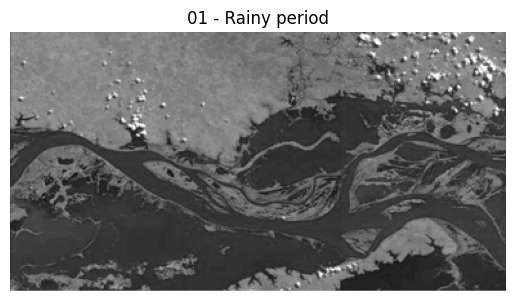

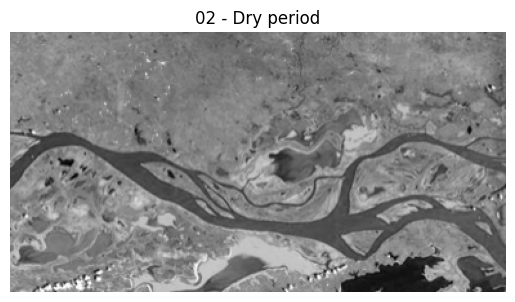

In [5]:
rainy, dry = load_grayscale_images(cfg)
save_debug_step(cfg, 1, "Rainy period", rainy)
save_debug_step(cfg, 2, "Dry period", dry)

## Steps 3–4: Histogram Equalization

Equalization redistributes intensity levels to span the full 0–255 range. This normalizes brightness differences caused by varying lighting conditions between the two captures, making the subsequent comparison more reliable.

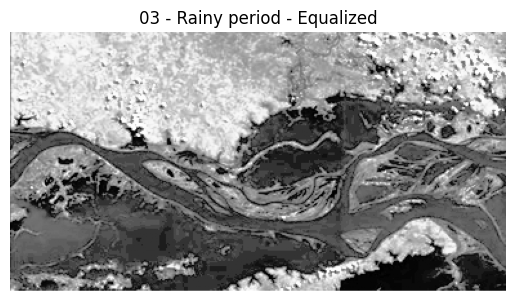

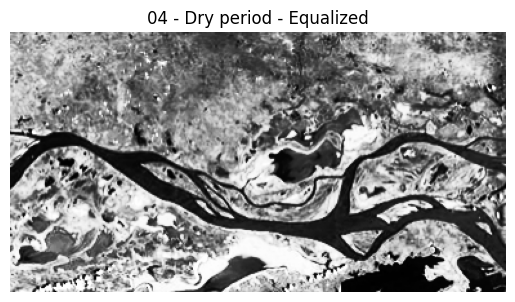

In [6]:
eq_rainy, eq_dry = equalize_images(rainy, dry)
save_debug_step(cfg, 3, "Rainy period - Equalized", eq_rainy)
save_debug_step(cfg, 4, "Dry period - Equalized", eq_dry)

## Steps 5–6: Inversion

Water appears dark in satellite imagery (low reflectance). Inverting the pixels flips water regions to high values (near 255), making them easy to isolate in the thresholding step ahead.

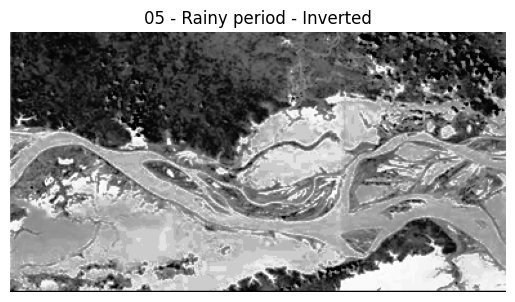

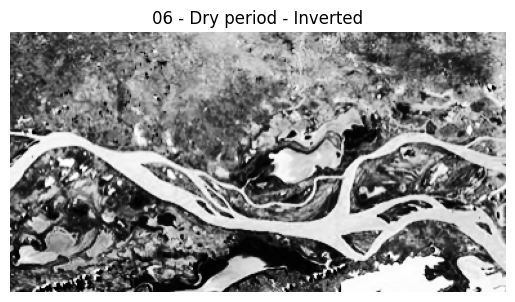

In [7]:
neg_rainy, neg_dry = invert_images(eq_rainy, eq_dry)
save_debug_step(cfg, 5, "Rainy period - Inverted", neg_rainy)
save_debug_step(cfg, 6, "Dry period - Inverted", neg_dry)

## Steps 7–8: Brightness Enhancement

A constant offset is added to every pixel to boost overall brightness. This pushes water pixels even closer to 255, widening the gap between water and non-water elements before binarization.

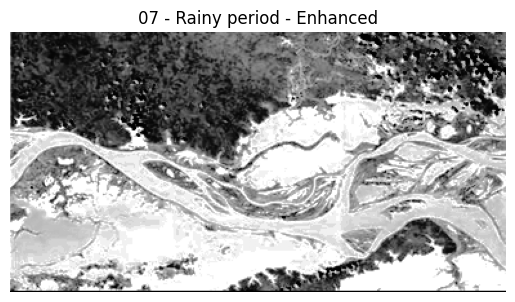

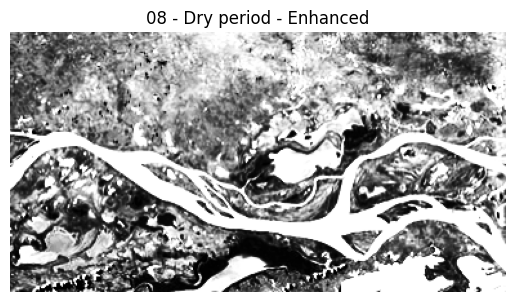

In [8]:
enh_rainy, enh_dry = enhance_images(cfg, neg_rainy, neg_dry)
save_debug_step(cfg, 7, "Rainy period - Enhanced", enh_rainy)
save_debug_step(cfg, 8, "Dry period - Enhanced", enh_dry)

## Steps 9–10: Morphological Operations

**Dilation** is applied to the rainy image: it expands water regions to fill small gaps introduced by noise or image resolution. **Erosion** is applied to the dry image: it shrinks water regions, discarding isolated pixels and reducing the impact of noise.

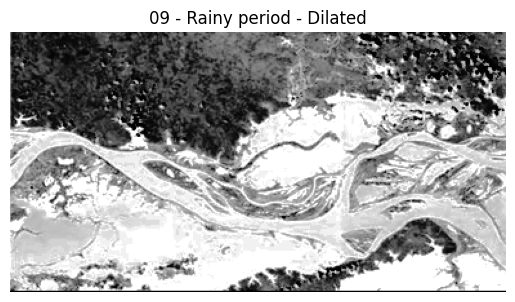

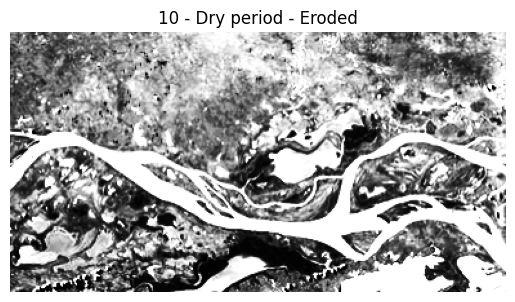

In [9]:
morph_rainy, morph_dry = apply_morphology(cfg, enh_rainy, enh_dry)
save_debug_step(cfg, 9, "Rainy period - Dilated", morph_rainy)
save_debug_step(cfg, 10, "Dry period - Eroded", morph_dry)

## Steps 11–12: Binarization

A threshold converts each image to binary: pixels above the threshold become white (255, water) and the rest become black (0). Separate thresholds are used for each image because, even after equalization, the two intensity distributions may differ.

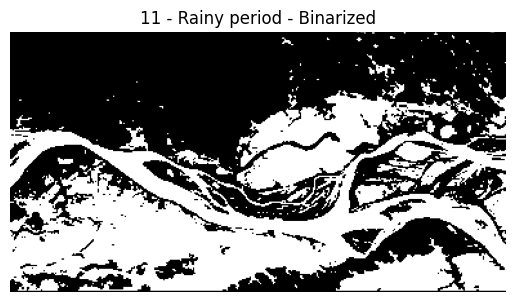

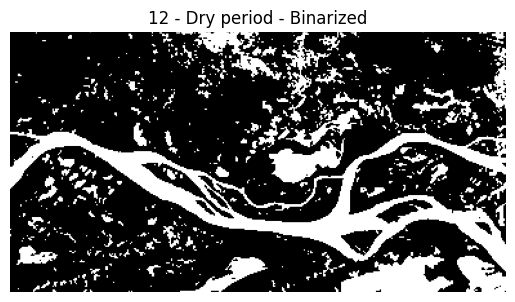

In [10]:
bin_rainy, bin_dry = binarize_images(cfg, morph_rainy, morph_dry)
save_debug_step(cfg, 11, "Rainy period - Binarized", bin_rainy)
save_debug_step(cfg, 12, "Dry period - Binarized", bin_dry)

## Step 13: Flood Detection

The dry-period water mask is subtracted from the rainy-period mask. What remains are pixels that were water during the rainy season but not during the dry season — i.e., the flooded areas. An optional morphological opening can be applied to remove residual noise from the result.

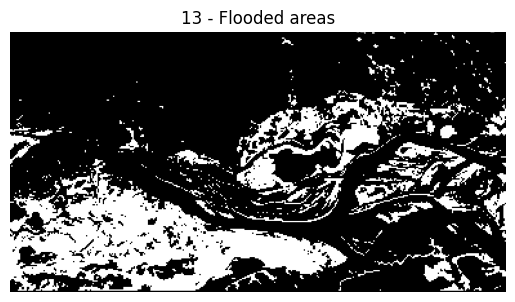

In [11]:
flooded = detect_flooded_areas(cfg, bin_rainy, bin_dry)
save_debug_step(cfg, 13, "Flooded areas", flooded)

## Step 14: Overlay Visualization

The flood mask is overlaid on the equalized dry-period image, coloring the detected flooded regions in blue. This gives an immediate visual reading of the flood extent against the actual geographic context. The total flooded area in pixels is printed at the end.

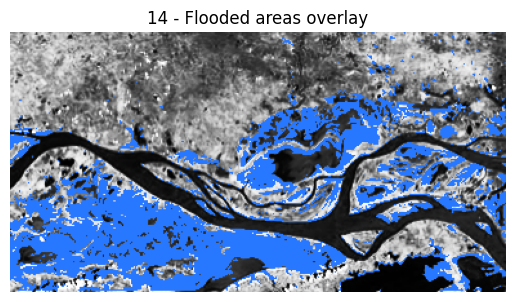

Flooded area: 19134 pixels


In [12]:
overlay = create_overlay(cfg, eq_dry, flooded)
save_debug_step(cfg, 14, "Flooded areas overlay", overlay)

area = calculate_flooded_area(flooded)
print(f"Flooded area: {area} pixels")